# 02 Modelado

*Autores: Verónica Gamo, Alexandru Stoia, Daniel Olivier Domínguez, Oliver Pereira*

**Empresa consultora: Stratton Oakmont Consulting**

En este notebook probaremos diversos modelos de simulación basados en árboles y AutoML:
1. `Custom Decision Tree` (Árbol de Decisión individual)
2. `RandomForestRegressor` (Bagging)
3. `GradientBoostingRegressor` (Boosting clásico)
4. `XGBRegressor` (Extreme Gradient Boosting)
5. `LGBMRegressor` (Light Gradient Boosting)
6. `CatBoost` (Gato Ruso con Esteroides)
7. `AutoGluon` (AutoML de nueva generación que entrena y emsambla múltiples modelos potentes automáticamente)

Aplicaremos One-Hot Encoding a las variables categóricas, usaremos `GridSearchCV` para buscar hiperparámetros óptimos y evaluaremos a través de validación el rendimiento de los modelos.
También **imprimiremos/graficaremos internamente la estructura de un Árbol de Decisión** para que la lógica de negocio resulte totalmente explicable.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, make_scorer
from sklearn.ensemble import RandomForestRegressor, VotingRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor, plot_tree
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

import warnings
warnings.filterwarnings('ignore')

# Inicializar SHAP javascript
shap.initjs()

# Configuración de los gráficos
plt.style.use('ggplot')
sns.set_palette("husl")

# Cargar los datos curados
df = pd.read_csv('data/processed_train_data.csv')
print("Dimensiones Datos Procesados:", df.shape)

# Transformar la altitud a variable continua explícitamente
df['ALTITUD'] = df['ALTITUD'].astype(float)

Dimensiones Datos Procesados: (8526, 18)


## 1. One-Hot Encoding e Imputación Final
Aplicamos variables dummy (One-Hot Encoding) a las variables categóricas evidentes en nuestro dataset.

In [2]:
# Excluimos 2022 si existiera
df = df[df['CAMPAÑA'] != 22]

categorical_cols = ['ID_ZONA', 'ID_ESTACION', 'VARIEDAD', 'MODO', 'TIPO', 'COLOR']

# Convertirlas a string temporalmente para que get_dummies actue sobre ellas
for col in categorical_cols:
    df[col] = df[col].astype(str)

# Hacemos el OHE
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Separamos Train Histórico (<= 2020) y Test (2021)
df_historico = df_encoded[df_encoded['CAMPAÑA'] <= 20].copy()
df_test = df_encoded[df_encoded['CAMPAÑA'] == 21].copy()

# Eliminar nulos en la variable objetivo del train histórico
df_historico.dropna(subset=['PRODUCCION'], inplace=True)

# Guardamos el X_test_output sin encode para recrear Mi_Solucion.txt según los ids originales
df_test_unencoded = df[df['CAMPAÑA'] == 21].copy()
X_test_output = df_test_unencoded[['ID_FINCA', 'VARIEDAD', 'MODO', 'TIPO', 'COLOR', 'SUPERFICIE']].copy()

# Features y Target totales
X_full = df_historico.drop(columns=['PRODUCCION'])
y_full = df_historico['PRODUCCION']

X_test_2021 = df_test.drop(columns=['PRODUCCION'])

# Alineamos las columnas de test con train
X_test_2021 = X_test_2021.reindex(columns=X_full.columns, fill_value=0)

# Split de validación (80% / 20%) 
X_train, X_val, y_train, y_val = train_test_split(X_full, y_full, test_size=0.2, random_state=42)
print("Tamaño del set de entrenamiento para búsqueda/evaluación OHE:", X_train.shape)
print("Tamaño del set de validación para evaluación final OHE:", X_val.shape)

Tamaño del set de entrenamiento para búsqueda/evaluación OHE: (5985, 180)
Tamaño del set de validación para evaluación final OHE: (1497, 180)


## 2. Visualización e Interpretabilidad: El Árbol de Decisión
Antes de ensayar con estimadores complejos, vamos a crear un modelo base compuesto por un **único Árbol de Decisión** y graficarlo. Esto nos permite entender qué reglas siguen los parámetros del modelo para separar las producciones.
Lo limitaremos a `max_depth=3` para que la gráfica resultante sea legible.

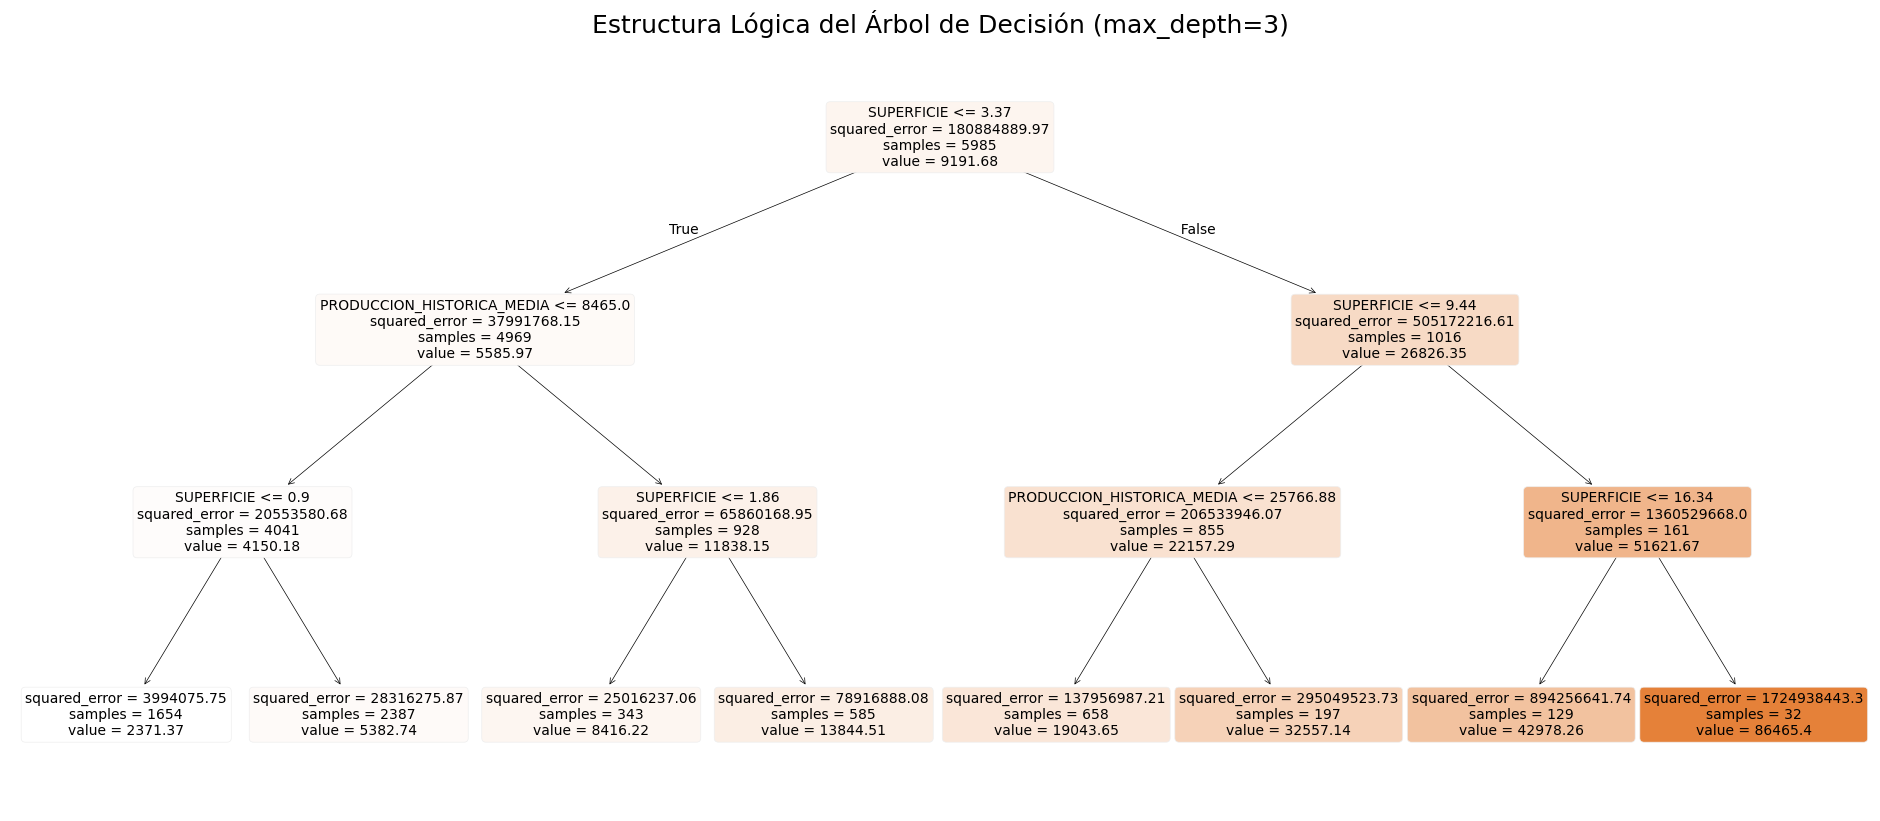

In [3]:
tree_visual = DecisionTreeRegressor(max_depth=3, random_state=42)
tree_visual.fit(X_train, y_train)

plt.figure(figsize=(24, 10))
plot_tree(tree_visual, 
          feature_names=X_train.columns, 
          filled=True, 
          rounded=True, 
          fontsize=10, 
          precision=2)
plt.title("Estructura Lógica del Árbol de Decisión (max_depth=3)", fontsize=18)
plt.show()

### Interpretación del Árbol de Decisión

El árbol mostrado resume reglas de decisión jerárquicas para estimar la **PRODUCCIÓN**.  
Cada nodo divide los datos según la variable y umbral más informativos en ese punto, por lo que las ramas superiores representan los factores con mayor impacto global.

Al limitar `max_depth=3`: cada hoja final agrupa parcelas con características similares y asigna una predicción promedio de producción.

Esta visualización permite identificar patrones y comprobar si las particiones tienen sentido antes de pasar a modelos más complejos.

## 3. Búsqueda de Hiperparámetros (GridSearchCV) para los modelos
Para comprobar empíricamente cuál es la técnica dominante, vamos a optimizar las métricas introduciendo también un Árbol de decisión simple (`DecisionTreeRegressor`) y el `GradientBoostingRegressor` clásico de Scikit-Learn.

In [4]:
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

score_rmse = make_scorer(rmse, greater_is_better=False)

param_grid_dt = {
    'max_depth': [5, 10, 15],
    'min_samples_split': [2, 5, 10]
}

param_grid_rf = {
    'n_estimators': [100, 300],
    'max_depth': [10, 15]
}

param_grid_gb = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [4, 6]
}

param_grid_xgb = {
    'n_estimators': [100, 300],
    'max_depth': [4, 6],
    'learning_rate': [0.05, 0.1]
}

param_grid_lgb = {
    'n_estimators': [100, 300],
    'max_depth': [6, 10],
    'learning_rate': [0.05, 0.1]
}

param_grid_cb = {
    'depth': [4, 6, 8],
    'learning_rate': [0.03, 0.1],
    'iterations': [200, 500],
    'l2_leaf_reg': [1, 3, 5]
}

# --- CatBoost ---
cb = CatBoostRegressor(
    loss_function='RMSE',
    random_state=42,
    verbose=0
)

# Declaramos Búsquedas

search_dt = GridSearchCV(DecisionTreeRegressor(random_state=42), param_grid=param_grid_dt, cv=3, scoring=score_rmse, n_jobs=-1)
search_rf = GridSearchCV(RandomForestRegressor(random_state=42, n_jobs=-1), param_grid=param_grid_rf, cv=3, scoring=score_rmse, n_jobs=-1)
search_gb = GridSearchCV(GradientBoostingRegressor(random_state=42), param_grid=param_grid_gb, cv=3, scoring=score_rmse, n_jobs=-1)
search_xgb = GridSearchCV(XGBRegressor(random_state=42, n_jobs=-1), param_grid=param_grid_xgb, cv=3, scoring=score_rmse, n_jobs=-1)
search_lgb = GridSearchCV(LGBMRegressor(random_state=42, n_jobs=-1, verbose=-1), param_grid=param_grid_lgb, cv=3, scoring=score_rmse, n_jobs=-1)
search_cb = GridSearchCV(
    cb,
    param_grid_cb,
    scoring=score_rmse,
    cv=3,
    n_jobs=-1
)

print("Buscando hiperparámetros...")
search_dt.fit(X_train, y_train)
search_rf.fit(X_train, y_train)
search_gb.fit(X_train, y_train)
search_xgb.fit(X_train, y_train)
search_lgb.fit(X_train, y_train)
search_cb.fit(X_train, y_train)

best_dt = search_dt.best_estimator_
best_rf = search_rf.best_estimator_
best_gb = search_gb.best_estimator_
best_xgb = search_xgb.best_estimator_
best_lgb = search_lgb.best_estimator_
best_cb = search_cb.best_estimator_

print("\nMejores hiperparámetros encontrados en validación cruzada:")
print("- Decision Tree:", search_dt.best_params_)
print("- Random Forest:", search_rf.best_params_)
print("- Gradient Boosting:", search_gb.best_params_)
print("- XGBoost:", search_xgb.best_params_)
print("- LightGBM:", search_lgb.best_params_)
print("- CatBoost:", search_cb.best_params_)

Buscando hiperparámetros...

Mejores hiperparámetros encontrados en validación cruzada:
- Decision Tree: {'max_depth': 5, 'min_samples_split': 10}
- Random Forest: {'max_depth': 15, 'n_estimators': 300}
- Gradient Boosting: {'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 200}
- XGBoost: {'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 100}
- LightGBM: {'learning_rate': 0.05, 'max_depth': 10, 'n_estimators': 100}
- CatBoost: {'depth': 8, 'iterations': 500, 'l2_leaf_reg': 5, 'learning_rate': 0.1}


## 4. Visualización Avanzada (Learning Curves y Feature Importance)

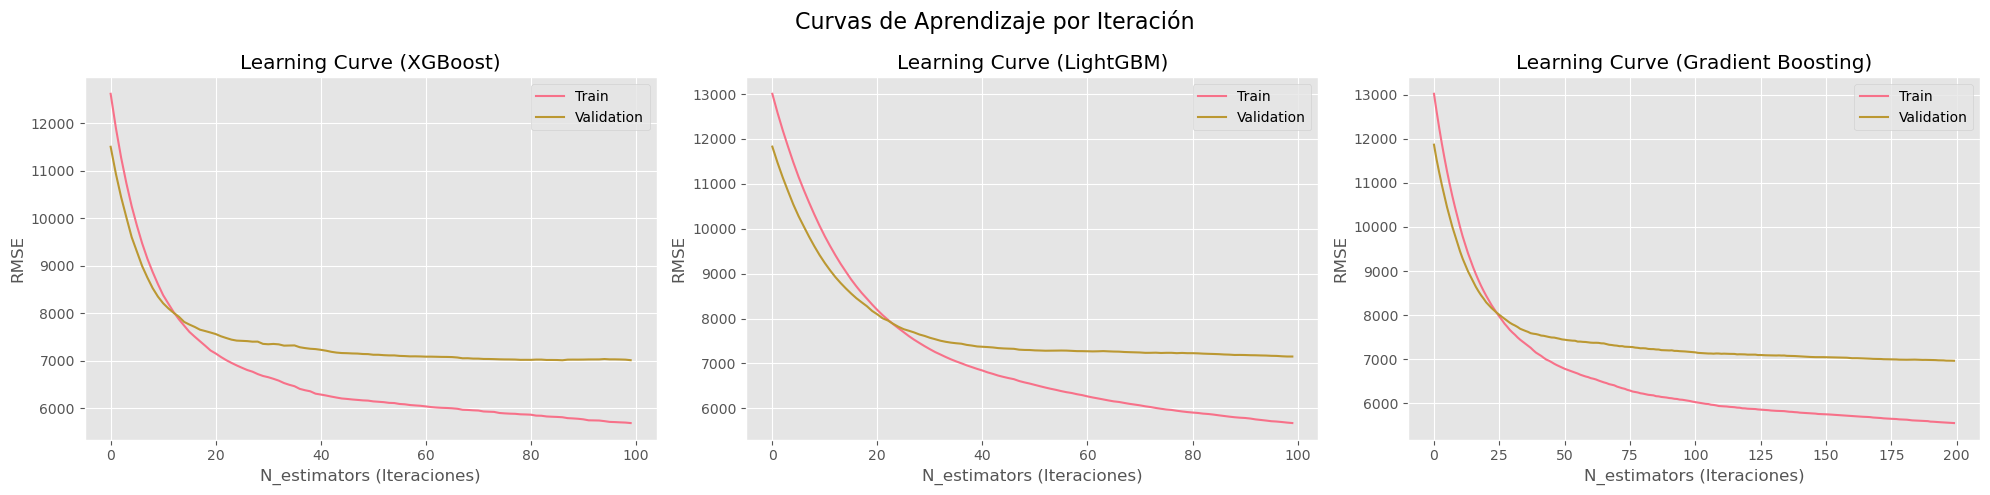

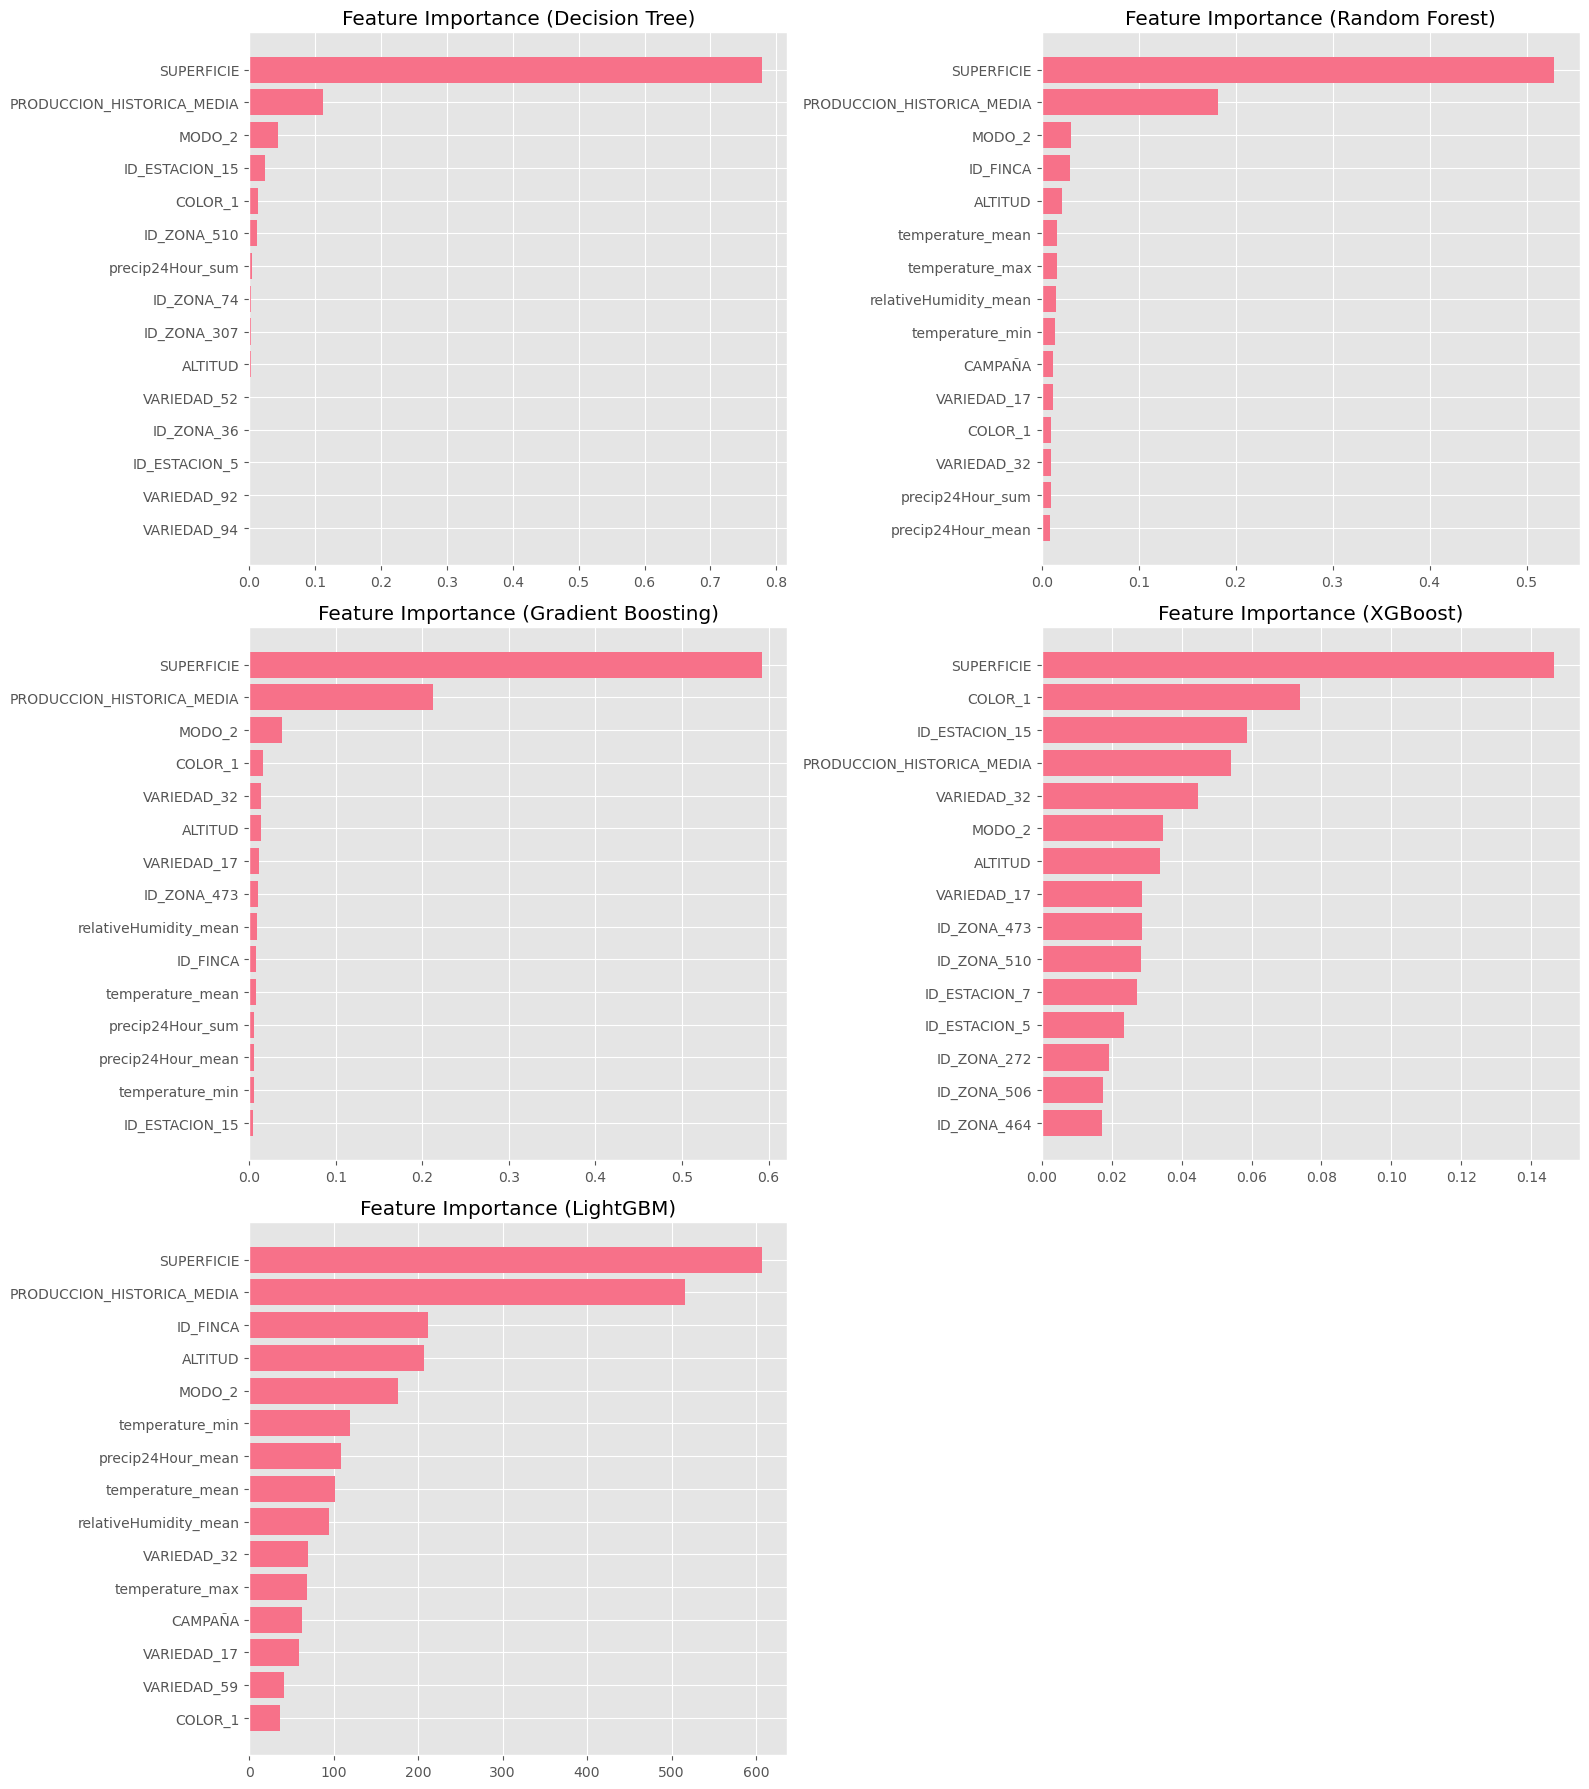

In [5]:
# --- Curvas de Aprendizaje (Learning Curves) para Boosting ---
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# 1. XGBoost
xgb_eval = XGBRegressor(**search_xgb.best_params_, random_state=42, n_jobs=-1)
xgb_eval.fit(X_train, y_train, eval_set=[(X_train, y_train), (X_val, y_val)], verbose=False)
resultados_xgb = xgb_eval.evals_result_

epochs_xgb = len(resultados_xgb['validation_0']['rmse'])
x_axis_xgb = range(0, epochs_xgb)
axes[0].plot(x_axis_xgb, resultados_xgb['validation_0']['rmse'], label='Train')
axes[0].plot(x_axis_xgb, resultados_xgb['validation_1']['rmse'], label='Validation')
axes[0].legend()
axes[0].set_ylabel('RMSE')
axes[0].set_xlabel('N_estimators (Iteraciones)')
axes[0].set_title('Learning Curve (XGBoost)')

# 2. LightGBM
lgb_eval = LGBMRegressor(**search_lgb.best_params_, random_state=42, n_jobs=-1, verbose=-1)
lgb_eval.fit(X_train, y_train, eval_set=[(X_train, y_train), (X_val, y_val)])
resultados_lgb = lgb_eval.evals_result_

epochs_lgb = len(resultados_lgb['training']['l2']) 
x_axis_lgb = range(0, epochs_lgb)
# LightGBM devuelve L2 (MSE), por lo que aplicamos np.sqrt para comparar con RMSE
axes[1].plot(x_axis_lgb, np.sqrt(resultados_lgb['training']['l2']), label='Train')
axes[1].plot(x_axis_lgb, np.sqrt(resultados_lgb['valid_1']['l2']), label='Validation')
axes[1].legend()
axes[1].set_ylabel('RMSE')
axes[1].set_xlabel('N_estimators (Iteraciones)')
axes[1].set_title('Learning Curve (LightGBM)')

# 3. Gradient Boosting Clásico (Scikit-Learn)
# Scikit-learn no usa eval_set por defecto, pero guarda el historial del 'train' en train_score_ y 
# ofrece staged_predict() para calcular el validation.
train_score_gb = np.zeros((search_gb.best_params_['n_estimators'],), dtype=np.float64)
val_score_gb = np.zeros((search_gb.best_params_['n_estimators'],), dtype=np.float64)

for i, y_pred in enumerate(best_gb.staged_predict(X_train)):
    train_score_gb[i] = rmse(y_train, y_pred)
    
for i, y_pred in enumerate(best_gb.staged_predict(X_val)):
    val_score_gb[i] = rmse(y_val, y_pred)
    
x_axis_gb = range(0, search_gb.best_params_['n_estimators'])
axes[2].plot(x_axis_gb, train_score_gb, label='Train')
axes[2].plot(x_axis_gb, val_score_gb, label='Validation')
axes[2].legend()
axes[2].set_ylabel('RMSE')
axes[2].set_xlabel('N_estimators (Iteraciones)')
axes[2].set_title('Learning Curve (Gradient Boosting)')

plt.suptitle("Curvas de Aprendizaje por Iteración", fontsize=16)
plt.tight_layout()
plt.show()

# --- Feature Importance para TODOS los modelos (excepto ensamblados o AutoML puro) ---

# Preparamos una lista solo con los modelos que pueden darnos feature importance
modelos_con_importancia = {
    'Decision Tree': best_dt,
    'Random Forest': best_rf,
    'Gradient Boosting': best_gb,
    'XGBoost': best_xgb,
    'LightGBM': best_lgb
}

# Calculamos cuantas filas necesitaremos (2 plots por fila)
n_modelos = len(modelos_con_importancia)
columnas = 2
filas = int(np.ceil(n_modelos / columnas))

fig, axes = plt.subplots(filas, columnas, figsize=(16, 6 * filas))
axes = axes.flatten() # Aplanamos el array de 2D a 1D para iterar mas facil

def plot_importance(model, title, ax):
    if hasattr(model, 'feature_importances_'):
        importances = model.feature_importances_
    else:
        importances = np.zeros(len(X_train.columns))
    
    # Mostrar solo el top 15 de features más importantes
    indices = np.argsort(importances)[-15:]
    ax.barh(range(len(indices)), importances[indices], align='center')
    ax.set_yticks(range(len(indices)), [X_train.columns[i] for i in indices])
    ax.set_title(title)

# Iteramos sobre nuestro diccionario
for i, (nombre, modelo) in enumerate(modelos_con_importancia.items()):
    plot_importance(modelo, f'Feature Importance ({nombre})', axes[i])

# Si tenemos un número impar de gráficos, oculta el último eje vacío
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


### Interpretación de las gráficas

En las **curvas de aprendizaje** (XGBoost, LightGBM y Gradient Boosting), se compara el error RMSE en entrenamiento y validación a lo largo de las iteraciones:

- Si ambas curvas bajan y se mantienen cercanas, el modelo **generaliza bien**.
- Si la curva de entrenamiento baja mucho más que la de validación, hay señales de **sobreajuste**.
- Si ambas curvas quedan altas, hay **infraajuste** (el modelo no capta bien el patrón).

Se puede observar que en estos tres modelos se consigue una buena generalización.

En las gráficas de **feature importance**, se muestran las 15 variables con mayor contribución en cada modelo:

- Barras más largas indican mayor influencia en la predicción.
- Si una variable aparece repetidamente entre las más importantes en varios modelos, su efecto es más **robusto**.
- Diferencias entre modelos son normales, porque cada algoritmo reparte la importancia de forma distinta.

## 4.5 AutoGluon AutoML
Autogluon es un framework avanzado que abstrae todo el pipeline de modelado entrenando automáticamente decenas de modelos (incluyendo combinaciones, apilados, redes neuronales, etc.).

In [6]:
# Es importante asegurar la variable objetivo y juntar X e y por exigencias de Autogluon
import warnings
warnings.filterwarnings('ignore')

try:
    from autogluon.tabular import TabularPredictor
    
    # AutoGluon necesita el dataframe completo (Features + Target)
    df_ag_train = X_train.copy()
    df_ag_train['PRODUCCION'] = y_train
    
    df_ag_val = X_val.copy()
    df_ag_val['PRODUCCION'] = y_val
    
    # Definimos el predictor (optimiza por RMSE, evitamos que demore más de 120s por rapidez)
    predictor = TabularPredictor(label='PRODUCCION', eval_metric='root_mean_squared_error').fit(
        train_data=df_ag_train, 
        tuning_data=df_ag_val,
        time_limit=120,
        presets='medium_quality'
    )
    
    # Leaderboard de los mejores modelos internamente hallados por AutoGluon
    print("\n--- Leaderboard de AutoGluon ---")
    leaderboard = predictor.leaderboard(df_ag_val)
    
    # Extraemos predicciones
    ag_preds = predictor.predict(X_val)
    print(f"AutoGluon Validation RMSE: {rmse(y_val, ag_preds)}")
    
    # Añadimos sus predicciones al DataFrame global del ensamble
    if 'predicciones_val' not in globals():
        predicciones_val = {}
    if 'modelos_sintonizados' not in globals():
        modelos_sintonizados = {}
        
    predicciones_val['AutoGluon'] = ag_preds
    modelos_sintonizados['AutoGluon'] = predictor
    
except ImportError:
    print("AutoGluon no está instalado en este entorno. Usa: pip install autogluon")



No path specified. Models will be saved in: "AutogluonModels\ag-20260310_175307"
Verbosity: 2 (Standard Logging)
	Failed to import torch or check CUDA availability!Please ensure you have the correct version of PyTorch installed by running `pip install -U torch`
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.13.5
Operating System:   Windows
Platform Machine:   AMD64
Platform Version:   10.0.26200
CPU Count:          8
Pytorch Version:    Can't import torch
CUDA Version:       Can't get cuda version from torch
Memory Avail:       7.33 GB / 31.48 GB (23.3%)
Disk Space Avail:   559.77 GB / 952.43 GB (58.8%)
Presets specified: ['medium_quality']
Using hyperparameters preset: hyperparameters='default'
Beginning AutoGluon training ... Time limit = 120s
AutoGluon will save models to "c:\Users\olive\OneDrive\Desktop\Académico\MASTER IA & BIG DATA\7. Aprendizaje Automático & Profundo\Proyecto Final\TF_AprendizajeAutom-tico\AutogluonModels\ag-2

[1000]	valid_set's rmse: 6697.67
[2000]	valid_set's rmse: 6642.17
[3000]	valid_set's rmse: 6609.51
[4000]	valid_set's rmse: 6606.01


	-6600.364	 = Validation score   (-root_mean_squared_error)
	8.32s	 = Training   runtime
	0.11s	 = Validation runtime
Fitting model: LightGBM ... Training model for up to 111.11s of the 111.11s of remaining time.
	Failed to import torch or check CUDA availability!Please ensure you have the correct version of PyTorch installed by running `pip install -U torch`
	Fitting with cpus=8, gpus=0, mem=0.1/7.3 GB


[1000]	valid_set's rmse: 6989.89


	-6979.2171	 = Validation score   (-root_mean_squared_error)
	2.37s	 = Training   runtime
	0.02s	 = Validation runtime
Fitting model: RandomForestMSE ... Training model for up to 108.66s of the 108.65s of remaining time.
	Failed to import torch or check CUDA availability!Please ensure you have the correct version of PyTorch installed by running `pip install -U torch`
	Fitting with cpus=8, gpus=0, mem=0.0/7.2 GB
	-6837.9569	 = Validation score   (-root_mean_squared_error)
	7.53s	 = Training   runtime
	0.07s	 = Validation runtime
Fitting model: CatBoost ... Training model for up to 100.80s of the 100.80s of remaining time.
	Failed to import torch or check CUDA availability!Please ensure you have the correct version of PyTorch installed by running `pip install -U torch`
	Fitting with cpus=8, gpus=0
	-6211.4942	 = Validation score   (-root_mean_squared_error)
	75.58s	 = Training   runtime
	0.01s	 = Validation runtime
Fitting model: ExtraTreesMSE ... Training model for up to 25.16s of the 2

[1000]	valid_set's rmse: 6522.23


	Ran out of time, early stopping on iteration 1885. Best iteration is:
	[1611]	valid_set's rmse: 6517.25
	-6517.2478	 = Validation score   (-root_mean_squared_error)
	16.21s	 = Training   runtime
	0.09s	 = Validation runtime
Fitting model: WeightedEnsemble_L2 ... Training model for up to 119.75s of the -0.68s of remaining time.
	Failed to import torch or check CUDA availability!Please ensure you have the correct version of PyTorch installed by running `pip install -U torch`
	Fitting 1 model on all data | Fitting with cpus=8, gpus=0, mem=0.0/5.5 GB
	Ensemble Weights: {'CatBoost': 0.6, 'ExtraTreesMSE': 0.2, 'LightGBMLarge': 0.12, 'XGBoost': 0.08}
	-6147.3831	 = Validation score   (-root_mean_squared_error)
	0.01s	 = Training   runtime
	0.0s	 = Validation runtime
AutoGluon training complete, total runtime = 120.78s ... Best model: WeightedEnsemble_L2 | Estimated inference throughput: 6439.4 rows/s (1497 batch size)
TabularPredictor saved. To load, use: predictor = TabularPredictor.load("c


--- Leaderboard de AutoGluon ---
AutoGluon Validation RMSE: 6147.383056390512


These features in provided data are not utilized by the predictor and will be ignored: ['ID_ZONA_515', 'ID_ZONA_62', 'ID_ZONA_639', 'ID_ZONA_71', 'ID_ZONA_734', 'ID_ZONA_772', 'ID_ZONA_816', 'ID_ZONA_836', 'ID_ZONA_848', 'ID_ESTACION_1', 'ID_ESTACION_11', 'ID_ESTACION_13', 'ID_ESTACION_17', 'ID_ESTACION_4', 'ID_ESTACION_6']
Computing feature importance via permutation shuffling for 165 features using 1497 rows with 5 shuffle sets...


Calculando Permutation Feature Importance para AutoGluon (puede tardar un momento)...


	455.78s	= Expected runtime (91.16s per shuffle set)
	94.31s	= Actual runtime (Completed 5 of 5 shuffle sets)


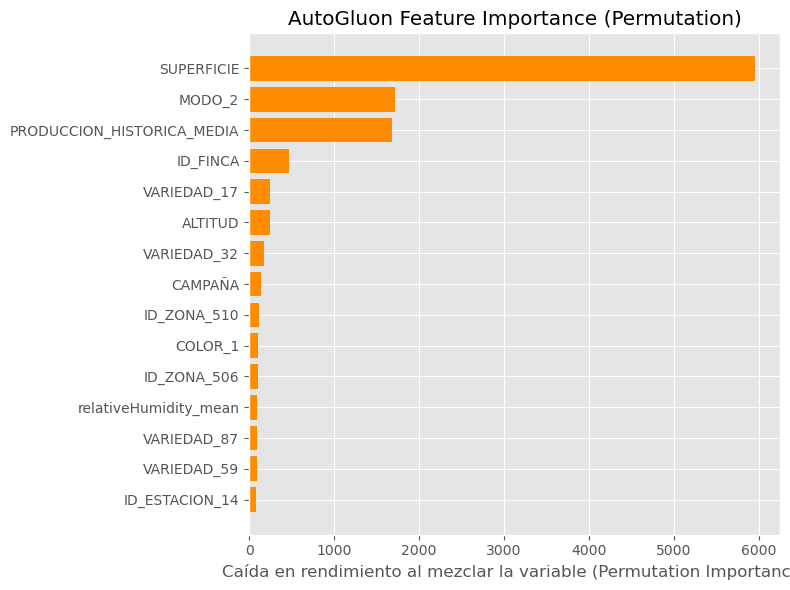

Resumen numérico de la importancia en AutoGluon:


,importance,stddev,p_value,n,p99_high,p99_low
SUPERFICIE,5953.437235,345.901094,1.361337e-06,5,6665.652368,5241.222103
MODO_2,1719.958506,211.978927,2.713534e-05,5,2156.426046,1283.490965
PRODUCCION_HISTORICA_MEDIA,1682.974320,57.812889,1.668349e-07,5,1802.011858,1563.936783
ID_FINCA,465.587875,54.046868,2.140394e-05,5,576.871122,354.304628
VARIEDAD_17,247.284159,39.252779,7.369301e-05,5,328.106174,166.462143
ALTITUD,240.606028,75.996583,1.050661e-03,5,397.084042,84.128013
VARIEDAD_32,175.894266,54.922204,1.006278e-03,5,288.979843,62.808688
CAMPAÑA,140.548267,49.420303,1.567092e-03,5,242.305354,38.791179
ID_ZONA_510,118.634592,59.332220,5.533033e-03,5,240.800452,-3.531268
COLOR_1,106.462531,38.461253,1.731627e-03,5,185.654784,27.270279


In [7]:
# --- Feature Importance para AutoGluon (Permutation Importance) ---
if 'AutoGluon' in modelos_sintonizados:
    print("Calculando Permutation Feature Importance para AutoGluon (puede tardar un momento)...")
    
    ag_predictor_final = modelos_sintonizados['AutoGluon']
    
    # Necesitamos el dataframe de validación unido con su target como lo necesita AutoGluon
    df_ag_val = X_val.copy()
    df_ag_val['PRODUCCION'] = y_val
    
    # Calculamos la métrica de feature importance interno de autogluon
    ag_importance = ag_predictor_final.feature_importance(df_ag_val)
    
    # El resultado de AutoGluon es un DataFrame ordenado por importancia. 
    # Extraemos las 15 variables más importantes
    top_15_ag = ag_importance.head(15).sort_values(by='importance', ascending=True)
    
    fig, ax = plt.subplots(figsize=(8, 6))
    # Usamos el campo 'importance' del DataFrame resultante
    ax.barh(top_15_ag.index, top_15_ag['importance'], align='center', color='darkorange')
    ax.set_title('AutoGluon Feature Importance (Permutation)')
    ax.set_xlabel('Caída en rendimiento al mezclar la variable (Permutation Importance)')
    
    plt.tight_layout()
    plt.show()
    
    print("Resumen numérico de la importancia en AutoGluon:")
    display(ag_importance.head(10))
else:
    print("AutoGluon no está en el diccionario de modelos. Asegúrate de haberlo entrenado.")


## 5. Evaluación de Modelos y Ensamblado Final
Evaluamos los cinco modelos en el set de validación e introducimos el `VotingRegressor`, integrando los algoritmos de ensamblado más estable.

In [11]:
# Actualizar el diccionario evitando borrar AutoGluon si ya existe
from catboost import CatBoost


if 'modelos_sintonizados' not in locals():
    modelos_sintonizados = {}
modelos_sintonizados.update({
    'Decision Tree': best_dt,
    'Gradient Boosting': best_gb,
    'RandomForest': best_rf,
    'XGBoost': best_xgb,
    'LightGBM': best_lgb,
    'CatBoost': best_cb
})

resultados = []
if 'predicciones_val' not in locals():
    predicciones_val = {}

# Recorremos los modelos para añadirlos a los resultados
for nombre, modelo in modelos_sintonizados.items():
    # AutoGluon se evaluó en su propia celda y no usa el predict tradicional de scikit
    if nombre == 'AutoGluon':
        if 'AutoGluon' in predicciones_val:
            preds = predicciones_val['AutoGluon']
            resultados.append({
                'Modelo': nombre,
                'RMSE': rmse(y_val, preds),
                'MAE': mean_absolute_error(y_val, preds),
                'R2': r2_score(y_val, preds)
            })
        continue

    preds = modelo.predict(X_val)
    preds = np.maximum(preds, 0)
    predicciones_val[nombre] = preds
    
    resultados.append({
        'Modelo': nombre,
        'RMSE': rmse(y_val, preds),
        'MAE': mean_absolute_error(y_val, preds),
        'R2': r2_score(y_val, preds)
    })

print("Entrenando Ensamblado (VotingRegressor)...")
# Nota: VotingRegressor solo usa modelos compatibles de Scikit-Learn
ensemble_val = VotingRegressor([
    ('rf', best_rf),
    ('gb', best_gb),
    ('xgb', best_xgb),
    ('lgb', best_lgb),
    ('cb', best_cb)
])
ensemble_val.fit(X_train, y_train)

preds_ens = ensemble_val.predict(X_val)
preds_ens = np.maximum(preds_ens, 0)
predicciones_val['Ensamblado'] = preds_ens

resultados.append({
    'Modelo': 'Ensamblado (RF+GB+XGB+LGB+CB)', 
    'RMSE': rmse(y_val, preds_ens),
    'MAE': mean_absolute_error(y_val, preds_ens),
    'R2': r2_score(y_val, preds_ens)
})

df_resultados = pd.DataFrame(resultados).sort_values(by="RMSE")
display(df_resultados)


Entrenando Ensamblado (VotingRegressor)...


,Modelo,RMSE,MAE,R2
0,AutoGluon,6147.383056,3212.869894,0.746462
6,CatBoost,6321.016440,3516.333349,0.731937
7,Ensamblado (RF+GB+XGB+LGB+CB),6694.840650,3662.083433,0.699293
3,RandomForest,6846.412914,3595.346384,0.685523
2,Gradient Boosting,6963.507146,3859.638208,0.674674
4,XGBoost,7008.334773,3906.975641,0.670472
5,LightGBM,7153.098075,3815.239180,0.656718
1,Decision Tree,7644.706370,4268.072994,0.607911


## 6. Analisis SHAP - Explicabilidad
Usaremos valores **SHAP** sobre los dos mejores modelos para la métrica RMSE: Autogluon y CatBoost, para interpretar en qué dirección influyen las variables.

Generando SHAP Summary Plot para CatBoost...


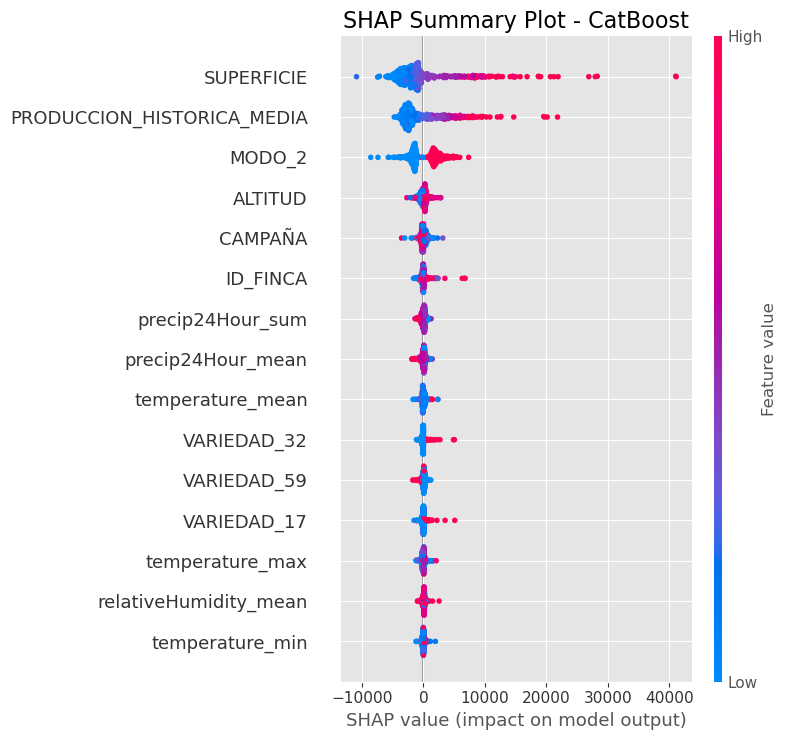

Generando SHAP Summary Plot para AutoGluon (puede tardar)...


  0%|          | 0/200 [00:00<?, ?it/s]

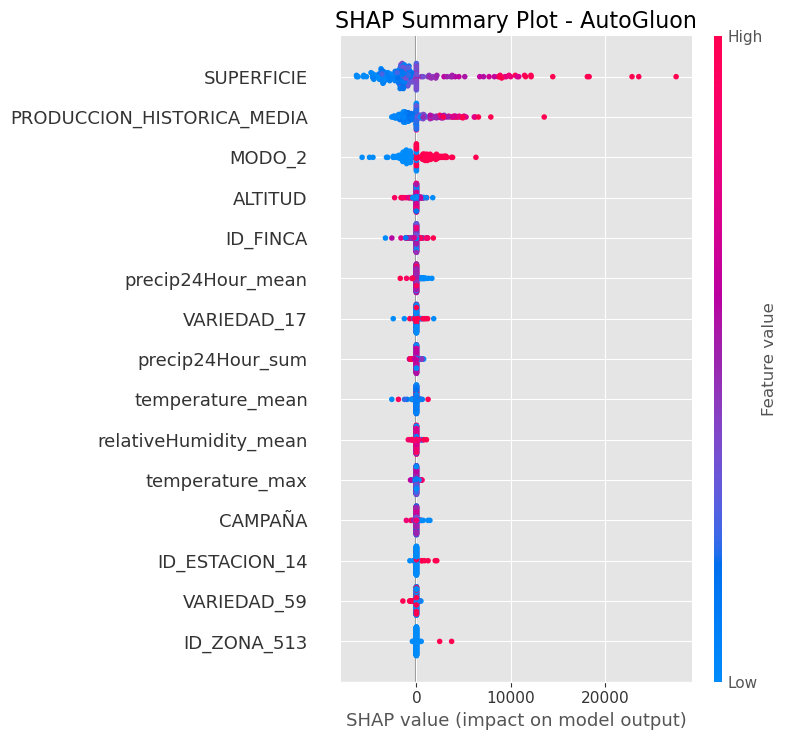

In [12]:
# --- SHAP para CatBoost y AutoGluon ---

# 1) SHAP para CatBoost 
print("Generando SHAP Summary Plot para CatBoost...")
X_val_cb = X_val.sample(min(500, len(X_val)), random_state=42)

explainer_cb = shap.TreeExplainer(best_cb)
shap_values_cb = explainer_cb.shap_values(X_val_cb)

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values_cb, X_val_cb, max_display=15, show=False)
plt.title("SHAP Summary Plot - CatBoost", fontsize=16)
plt.tight_layout()
plt.show()

# 2) SHAP para AutoGluon
if 'modelos_sintonizados' in globals() and 'AutoGluon' in modelos_sintonizados:
    print("Generando SHAP Summary Plot para AutoGluon...")
    ag_predictor = modelos_sintonizados['AutoGluon']

    # Muestreo para reducir coste computacional
    X_bg = X_train.sample(min(100, len(X_train)), random_state=42)
    X_explain = X_val.sample(min(200, len(X_val)), random_state=42)

    def predict_ag(x):
        x_df = pd.DataFrame(x, columns=X_train.columns)
        return ag_predictor.predict(x_df).to_numpy()

    explainer_ag = shap.KernelExplainer(predict_ag, X_bg)
    shap_values_ag = explainer_ag.shap_values(X_explain, nsamples=100)

    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_values_ag, X_explain, max_display=15, show=False)
    plt.title("SHAP Summary Plot - AutoGluon", fontsize=16)
    plt.tight_layout()
    plt.show()
else:
    print("AutoGluon no está disponible en modelos_sintonizados; no se genera su gráfico SHAP.")

### Interpretación de las gráficas SHAP (CatBoost y AutoGluon)

En ambos gráficos SHAP:

- El **eje Y** muestra las variables, ordenadas por importancia global.
- El **eje X** muestra el valor SHAP (impacto en la predicción de `PRODUCCION`):
  - SHAP > 0: empuja la predicción hacia valores más altos.
  - SHAP < 0: empuja la predicción hacia valores más bajos.
- El **color** indica el valor de la variable en cada observación:
  - Rojo: valor alto.
  - Azul: valor bajo.

---

#### 1) SHAP Summary Plot — **CatBoost**

Este gráfico explica cómo el modelo CatBoost utiliza cada variable para ajustar la predicción.

- Si los puntos rojos de una variable aparecen más a la **derecha**, valores altos de esa variable tienden a **aumentar** la producción.
- Si los puntos rojos aparecen más a la **izquierda**, valores altos tienden a **reducir** la producción.
- Una mayor dispersión horizontal implica un efecto más fuerte y variable entre fincas.

Como CatBoost se explica con `TreeExplainer`, esta interpretación suele ser más estable y precisa para modelos basados en árboles.

---

#### 2) SHAP Summary Plot — **AutoGluon**

Este gráfico muestra la contribución de variables en el predictor final de AutoGluon (posible ensamblado de varios modelos).

- Se interpreta igual que el de CatBoost (signo SHAP + color).
- Puede verse más “disperso” porque se usa `KernelExplainer`, que es una aproximación para modelos de caja negra.
- Aun así, permite identificar los **drivers globales** más influyentes sobre `PRODUCCION`.

---

En ambos gráficos de explicabilidad observamos que las variables con más dispersión - es decir más fuerza predictiva - son: `SUPERFICIE`, `PRODUCCIÓN HISTÓRICA MEDIA`Y `MODO_2`.

## 7. Gráficas Comparativas Globales y Análisis de Residuos

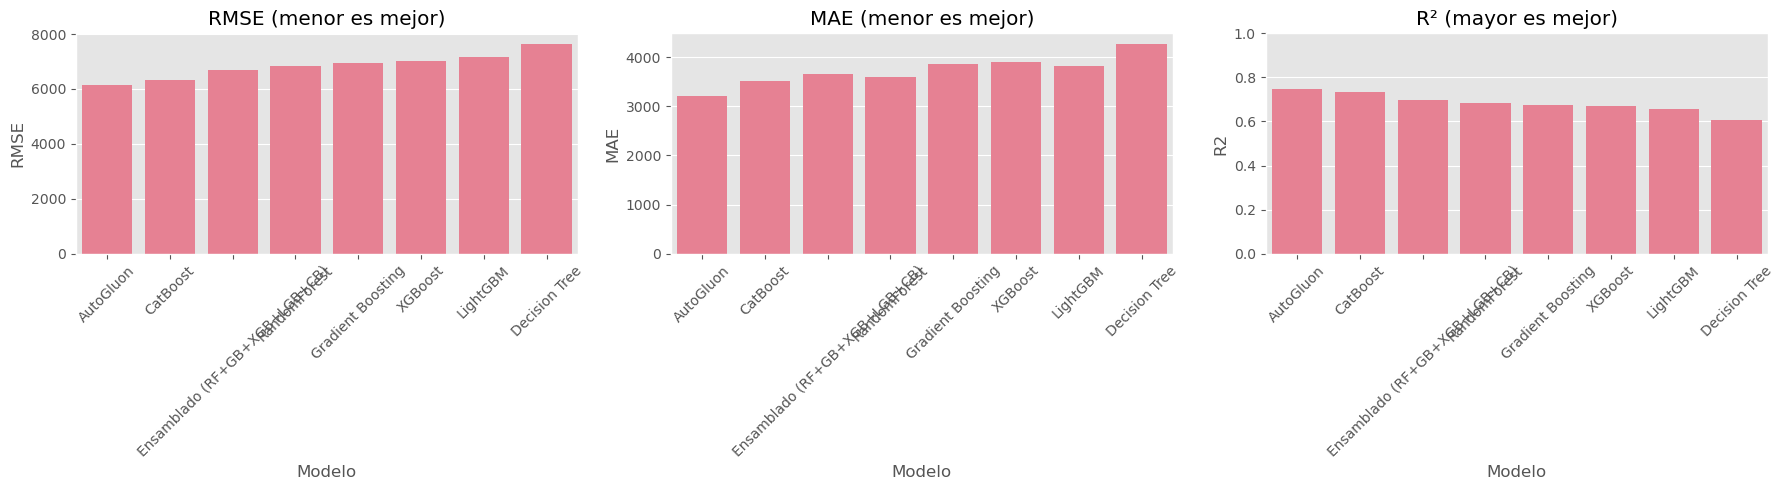

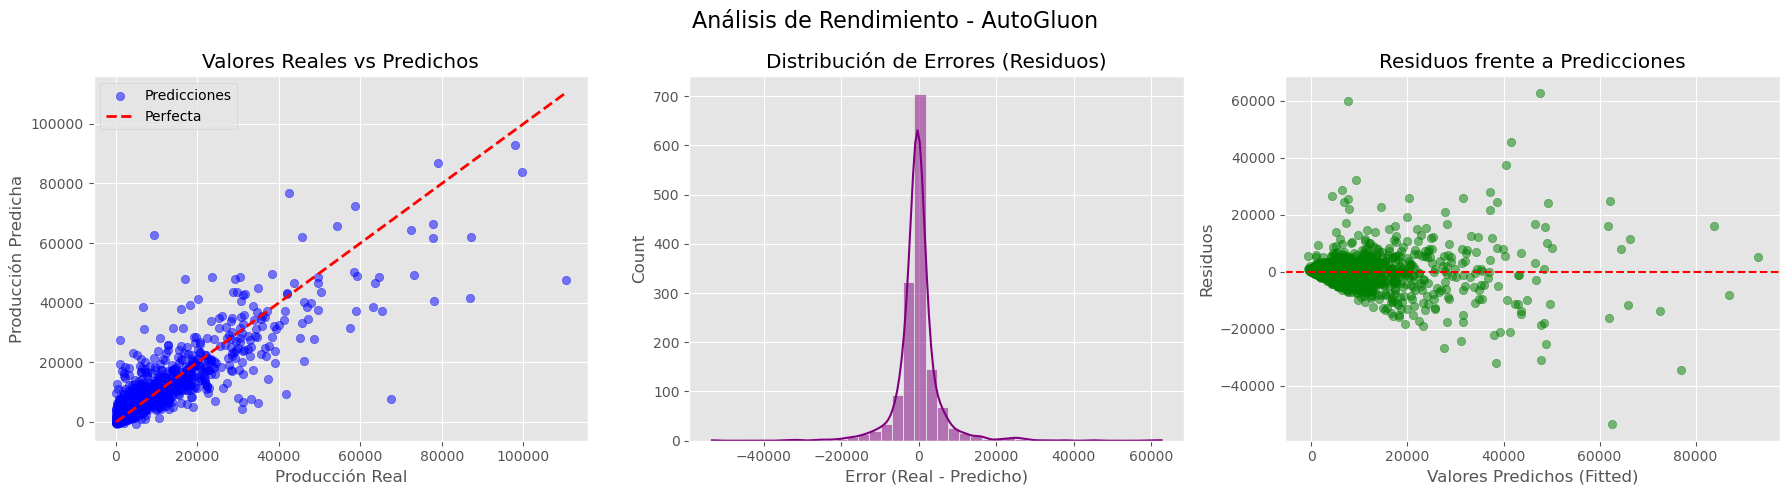

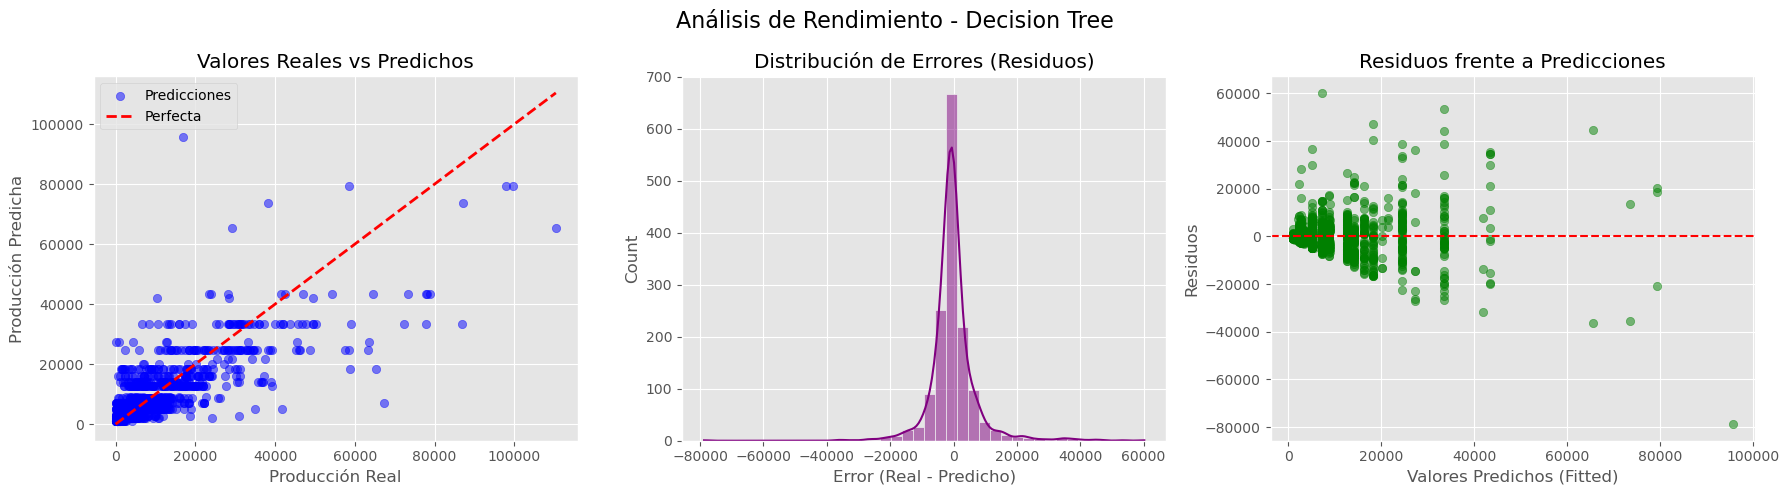

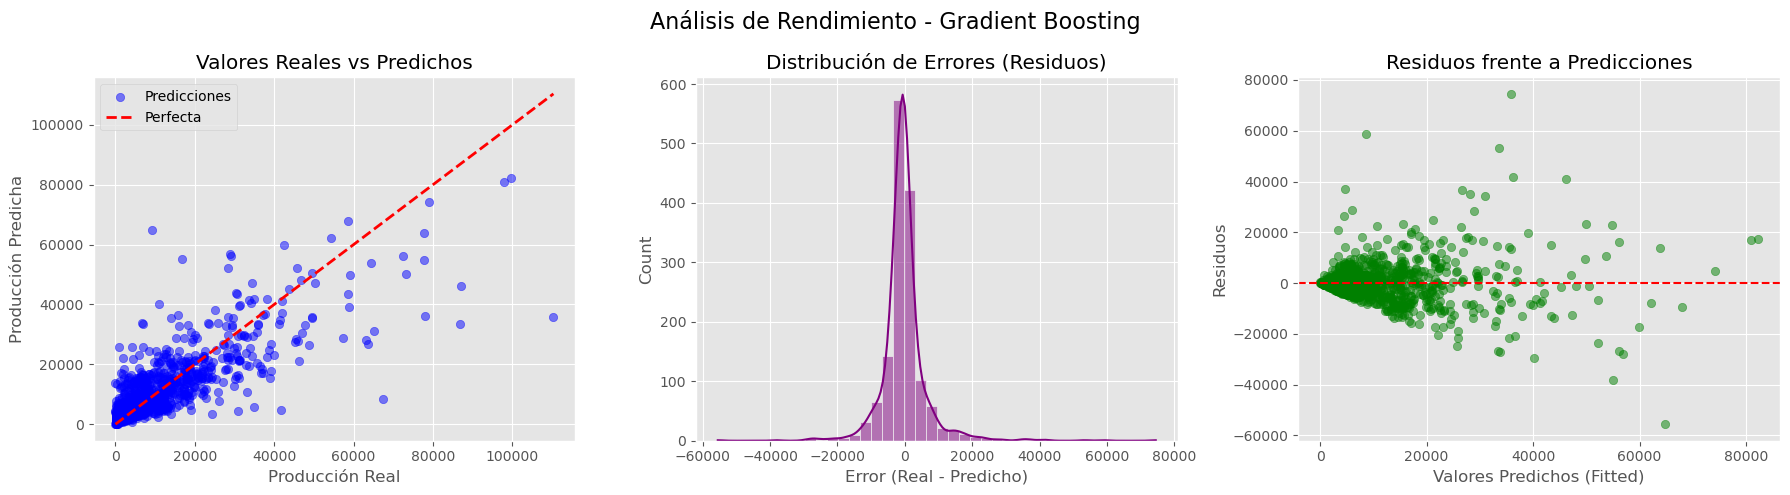

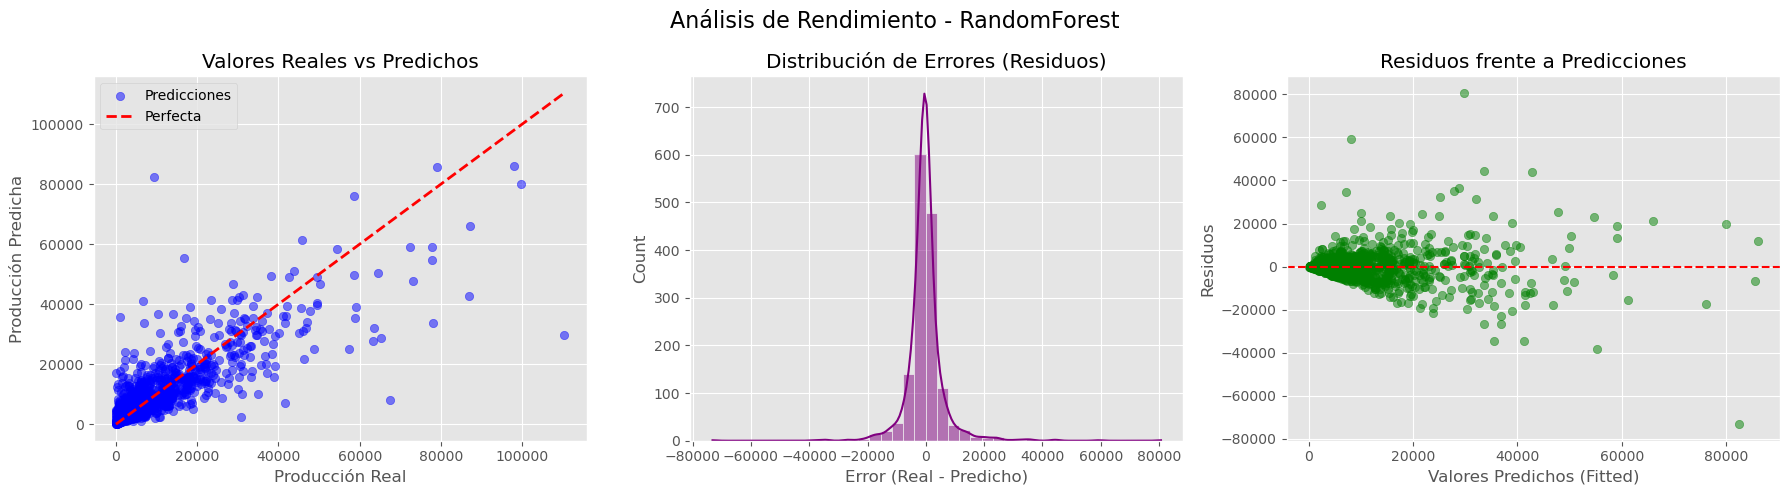

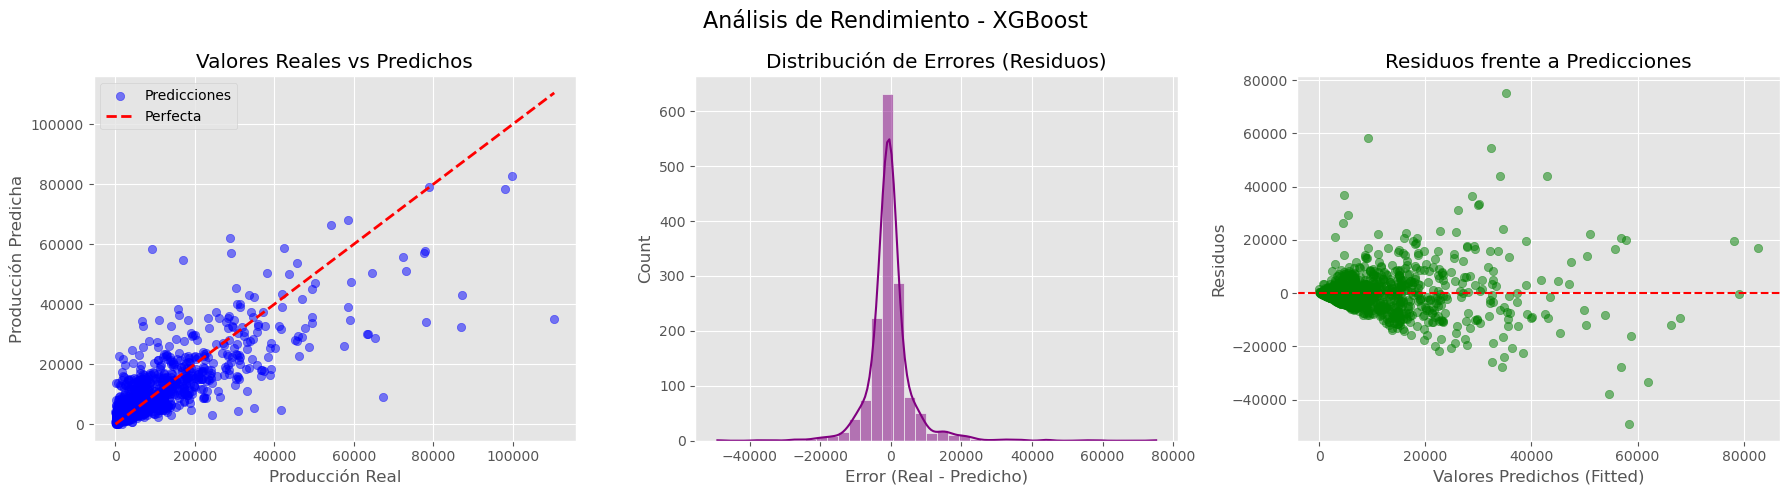

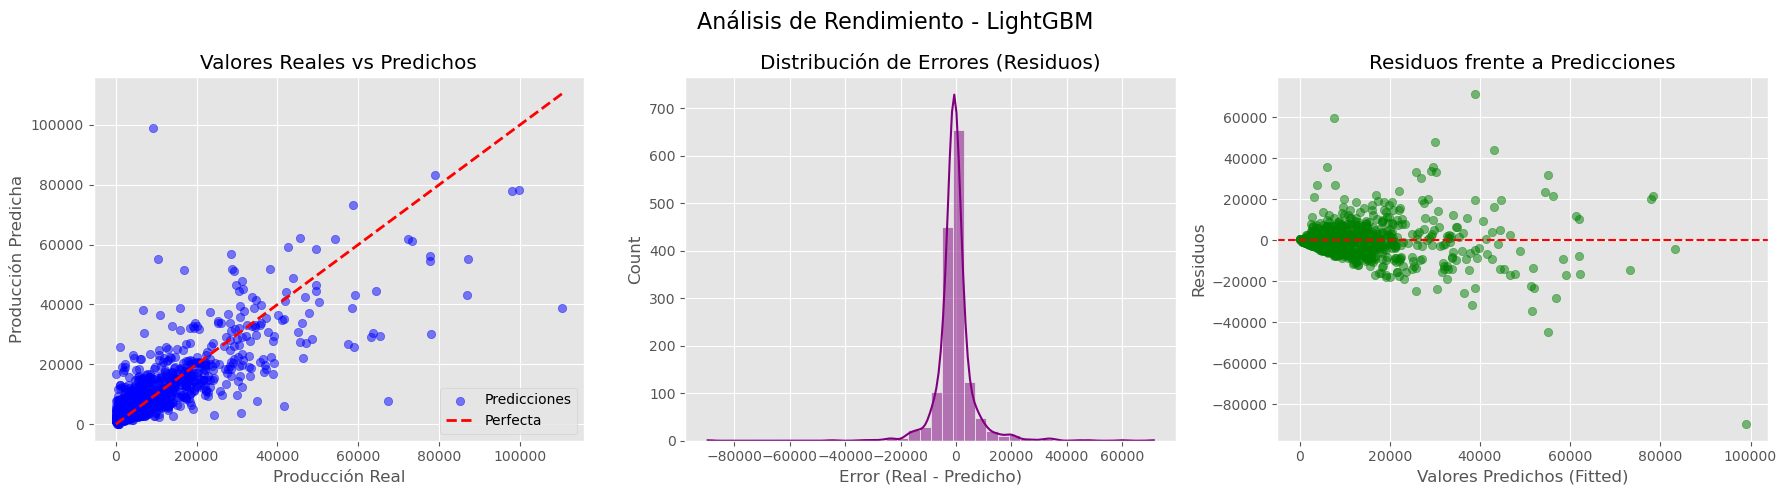

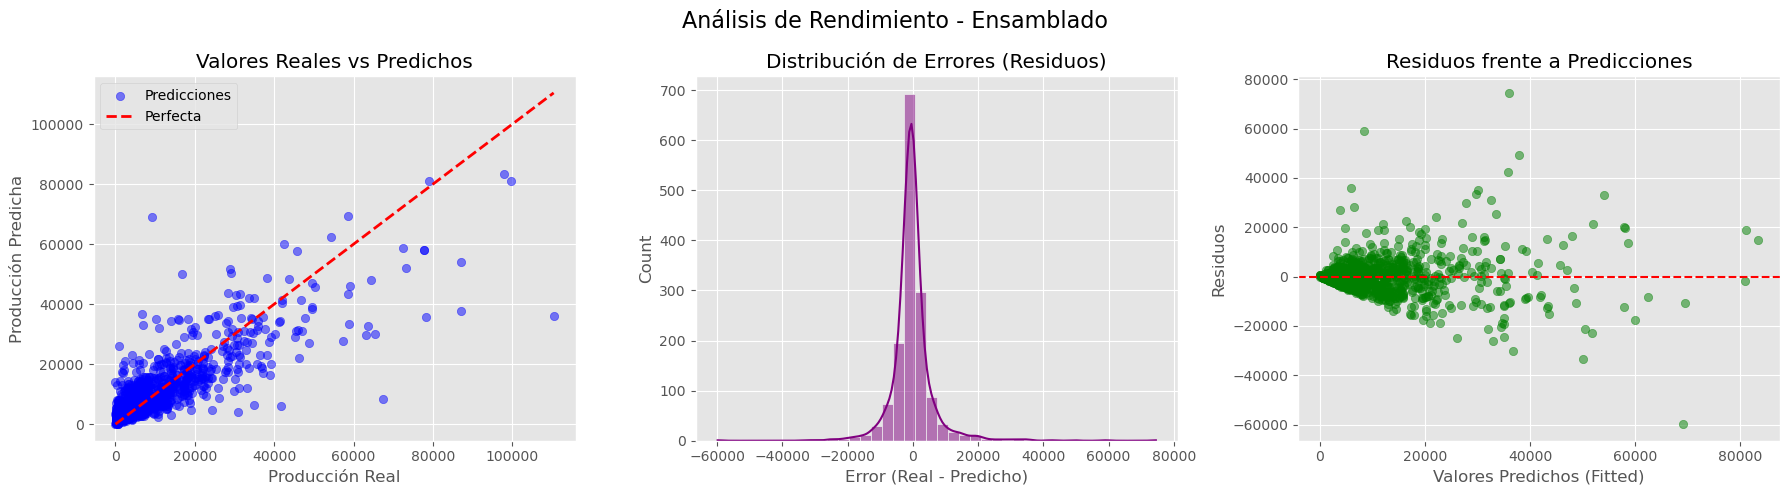

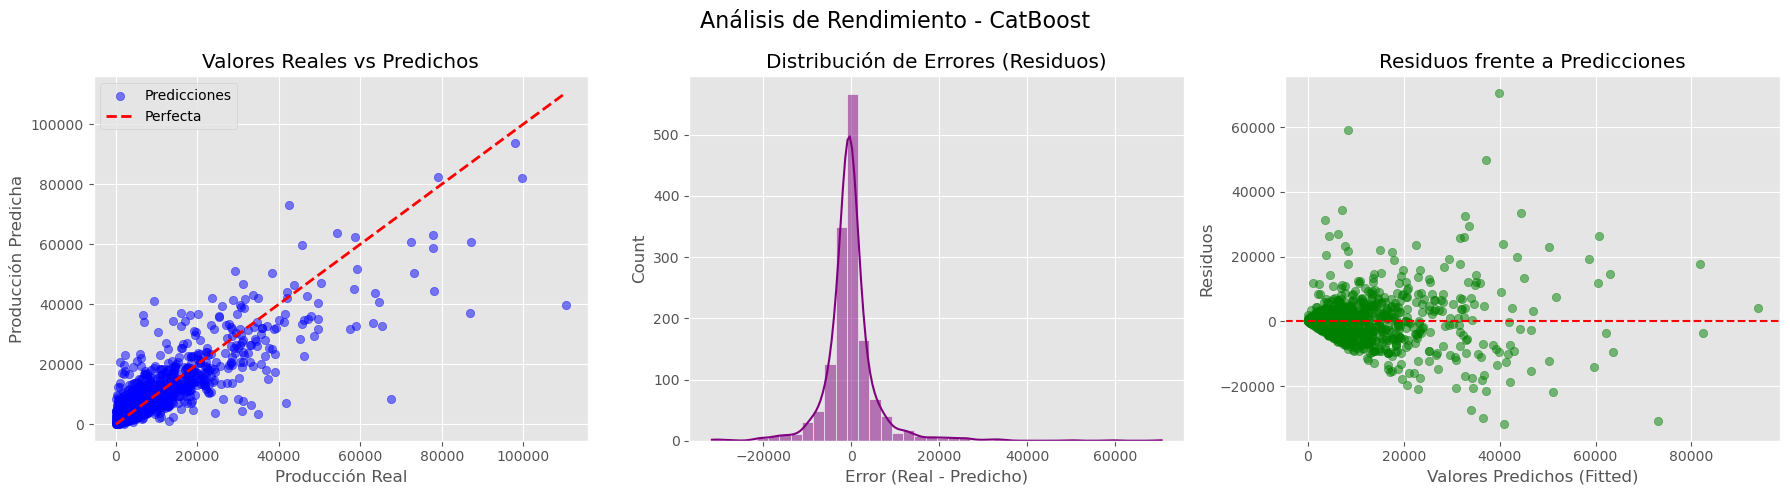

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.barplot(data=df_resultados, x='Modelo', y='RMSE', ax=axes[0])
axes[0].set_title('RMSE (menor es mejor)')
axes[0].tick_params(axis='x', rotation=45)
sns.barplot(data=df_resultados, x='Modelo', y='MAE', ax=axes[1])
axes[1].set_title('MAE (menor es mejor)')
axes[1].tick_params(axis='x', rotation=45)
sns.barplot(data=df_resultados, x='Modelo', y='R2', ax=axes[2])
axes[2].set_title('R² (mayor es mejor)')
axes[2].set_ylim(0, 1)
axes[2].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

# --- Análisis de Residuos individual para cada modelo ---
# Bucle for para graficar los resultados de TODOS los modelos en predicciones_val
for nombre_modelo, predicciones in predicciones_val.items():
    residuos = y_val - predicciones
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    # Scatter Real vs Predicha
    axes[0].scatter(y_val, predicciones, alpha=0.5, color='blue', label='Predicciones')
    axes[0].plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--', lw=2, label='Perfecta')
    axes[0].set_xlabel('Producción Real')
    axes[0].set_ylabel('Producción Predicha')
    axes[0].set_title(f'Valores Reales vs Predichos')
    axes[0].legend()
    # Histograma de Residuos
    sns.histplot(residuos, bins=40, kde=True, ax=axes[1], color='purple')
    axes[1].set_title(f'Distribución de Errores (Residuos)')
    axes[1].set_xlabel('Error (Real - Predicho)')
    # Residuos vs Fitted
    axes[2].scatter(predicciones, residuos, alpha=0.5, color='green')
    axes[2].axhline(0, color='r', linestyle='--')
    axes[2].set_xlabel('Valores Predichos (Fitted)')
    axes[2].set_ylabel('Residuos')
    axes[2].set_title(f'Residuos frente a Predicciones')
    # Añadimos un título principal indicando qué modelo se está graficando
    plt.suptitle(f"Análisis de Rendimiento - {nombre_modelo}", fontsize=16)
    plt.tight_layout()
    plt.show()

### Interpretación de las gráficas comparativas y de residuos

#### 1) Barras de métricas (RMSE, MAE y R²)

- **RMSE (menor es mejor)**: penaliza más los errores grandes.
- **MAE (menor es mejor)**: mide el error absoluto promedio, más robusto a outliers que RMSE.
- **R² (mayor es mejor)**: proporción de variabilidad explicada por el modelo.

Observamos que `Autogluon` es el modelo que consigue las mejores métricas de manera general.

---

#### 2) Real vs Predicho

- Cada punto compara una observación real con su predicción.
- La línea roja discontinua representa la predicción perfecta (`y = x`).
- Cuanto más cerca estén los puntos de la línea, mejor ajusta el modelo.

Patrones útiles:
- Puntos sistemáticamente por encima/debajo de la línea sugieren sesgo.
- Mayor dispersión en valores altos puede indicar más dificultad en producciones extremas.

---

#### 3) Histograma de residuos (`Real - Predicho`)

- Idealmente centrado en **0** y con forma aproximadamente simétrica.
- Residuos positivos: el modelo **infraestima**.
- Residuos negativos: el modelo **sobreestima**.

Si la distribución está desplazada de 0, puede haber sesgo global.

---

#### 4) Residuos vs Predicciones (Fitted)

- Se busca una nube aleatoria alrededor de la línea 0.
- Si aparece forma de embudo, hay **heterocedasticidad** (error no constante).
- Si hay curvas o patrones, faltan relaciones no lineales/interacciones por capturar.

En conjunto, estas gráficas permiten elegir no solo el modelo con mejor métrica, sino también el más **estable y fiable** en distintos rangos de producción.

## 8. Exportación Final (Campaña 2021)


In [15]:
print("Haciendo la predicción final de la campaña 2021 usando AutoGluon...")

# Nos aseguramos de tener un dataframe compatible con AutoGluon
df_ag_test_2021 = X_test_2021.copy()

# AutoGluon fue entrenado previamente y guardado en 'predictor' (dentro de modelos_sintonizados)
if 'AutoGluon' in modelos_sintonizados:
    ag_predictor_final = modelos_sintonizados['AutoGluon']
    # Como AutoGluon ya evaluó múltiples modelos complejos y ensamblados y guardó el mejor,
    # utilizamos ese modelo optimizado directamente.
    print("Usando el modelo AutoGluon previamente entrenado")
    y_pred_2021 = ag_predictor_final.predict(df_ag_test_2021)
else:
    print("No se encontró AutoGluon, usando el Ensamblado (VotingRegressor)...")
    model_rf_final = RandomForestRegressor(**search_rf.best_params_, random_state=42, n_jobs=-1)
    model_gb_final = GradientBoostingRegressor(**search_gb.best_params_, random_state=42)
    model_xgb_final = XGBRegressor(**search_xgb.best_params_, random_state=42, n_jobs=-1)
    model_lgb_final = LGBMRegressor(**search_lgb.best_params_, random_state=42, n_jobs=-1, verbose=-1)
    model_cb_final = CatBoostRegressor(**search_cb.best_params_, random_state=42, verbose=False)
    print("Reentrenando Ensamblado en todo el histórico completo...")
    ensemble_final = VotingRegressor([
        ('rf', model_rf_final),
        ('gb', model_gb_final),
        ('xgb', model_xgb_final),
        ('lgb', model_lgb_final),
        ('cb', model_cb_final)
    ])
    ensemble_final.fit(X_full, y_full)
    y_pred_2021 = ensemble_final.predict(X_test_2021)

y_pred_2021 = np.maximum(y_pred_2021, 0)

# Preparar DataFrame de respuesta
df_res = X_test_output.copy()
df_res['PRODUCCION'] = y_pred_2021

# Para asegurar el ordenamiento correcto
df_res['VARIEDAD'] = pd.to_numeric(df_res['VARIEDAD'])
df_res['MODO'] = pd.to_numeric(df_res['MODO'])
df_res['TIPO'] = pd.to_numeric(df_res['TIPO'])
df_res['COLOR'] = pd.to_numeric(df_res['COLOR'])

cols_sort = ['ID_FINCA', 'VARIEDAD', 'MODO', 'TIPO', 'COLOR', 'SUPERFICIE']
df_res.sort_values(by=cols_sort, ascending=True, inplace=True)

df_res['PRODUCCION'] = df_res['PRODUCCION'].round(2)

print("Filas del dataframe generado:", df_res.shape[0])

# Guardar a txt sin cabecera y con separador ;
df_res.to_csv('strattonoakmont.txt', sep=';', index=False, header=False)
print("Se ha generado strattonoakmont.txt exitosamente.")


Haciendo la predicción final de la campaña 2021 usando AutoGluon...
Usando el modelo AutoGluon previamente entrenado
Filas del dataframe generado: 1044
Se ha generado strattonoakmont.txt exitosamente.
